# 1.5 確率的勾配降下法（SGD）

**原典**: scikit-learn User Guide [1.5. Stochastic Gradient Descent](https://scikit-learn.org/stable/modules/sgd.html)（v1.9.1）

| | |
|---|---|
| **このノートで分かるようになること** | ・SGD が「モデル」ではなく「学習のやり方（最適化手法）」であることを説明できる<br>・`SGDClassifier` / `SGDRegressor` が、ロジスティック回帰・線形 SVM・Ridge などと同じ問題を解いていることを確かめられる<br>・学習率、平均化（ASGD）、早期停止、スケーリングなど、SGD を使いこなすコツが分かる<br>・SGD の 1 回の更新が何をしているかを言葉で説明でき、自分で書いた更新と scikit-learn の結果を照合できる（式は数式編） |
| **前提** | [1.1 線形モデル（3/4）](./01_linear_models_3_classification_glm.ipynb)の SGD の節、[1.4 SVM](./04_svm_1_classification_regression.ipynb)（ヒンジ損失、One-Class SVM） |
| **目安時間** | 90〜120 分 |

### 🗺️ 3 行でいうと

1. **SGD** は「モデル」ではなく「学習のやり方」。データを 1 件ずつ見て、そのたびに係数を少しだけ直す。
2. 1 歩は不正確だがとても安いので、**大量のデータ**や**次々に届くデータ**に向く。損失と正則化を選ぶだけで、ロジスティック回帰にも SVM にも Ridge にもなる。
3. うまく使うコツは、**標準化・シャッフル・`alpha` の探索・平均化（`average=True`）**。

> 📐 **数式について**: 本文は**数式なしで読める**ように書いています（中学修了程度の数学で足ります）。式で確かめたい人は [数式編](./math/05_sgd_math.md) へ。必要な数学の道具は [数学の準備](../00_math_primer.md)、用語は [用語集](../glossary.md) にまとめています。

### このノートの読み方

| 記号 | 意味 |
|---|---|
| 📖 **ガイドの解説** | 公式ガイドの内容を日本語で説明したもの |
| 💡 **補足** | 初学者向けに、ガイドにない前提知識・直感・たとえ話を足したもの |
| 📚 **用語** / 🔢 **数式を読む** | 初出の用語の説明 /（数式編の中で）数式の記号を 1 つずつ説明し、日本語で読み下したもの |
| 🎯 **なぜ使うのか** / 🏭 **利用例** / 🕰️ **歴史** | 手法が使われる理由・実際の応用・生まれた経緯（参考情報） |
| 🧪 **やってみよう** / 📈 **学習したモデルを見る** / 👀 **結果の読み方** | コードで確かめる / 学習したモデルを図で確かめる / 出力のどこを見ればよいか |
| ⚠️ **つまずきポイント** | 実際に動かして分かった落とし穴（ガイドに書かれていないものを含む） |
| 🏢 **実務での選ばれ方** | 実際の業務で、その手法が選ばれる場面・選ばれない場面・よく組み合わせる手法 |
| 💬 **ことばで言うと** / 📐 **数式編** | 式の意味を言葉だけで説明したもの / 式・記号の表・導き方をまとめた別ファイルへのリンク |

> ⚠️ このノートには**実行時間を測る**実験があります。時間の値は、実行するコンピュータによって変わります。

### 目次

0. 導入: SGD とは
1. 1.5.1 分類
2. 1.5.2 回帰
3. 1.5.3 オンライン One-Class SVM
4. 1.5.4 疎なデータの SGD
5. 1.5.5 計算量
6. 1.5.6 停止の基準
7. 1.5.7 実践のコツ
8. 1.5.8 しくみ（損失関数 / 正則化 / 更新 / 学習率 / 平均化。式は数式編）
9. 1.5.9 実装の詳細
10. まとめ・確認クイズ

## セットアップ

実行済みの出力つきで保存しています。手元で動かす場合は、上から順に実行してください。

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # グラフで日本語を表示するため

from sklearn import linear_model as lm

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.figsize": (6, 3.6), "figure.dpi": 80, "axes.grid": True})
rng = np.random.RandomState(0)  # 乱数の種を固定（同じ結果を再現するため）

import time
from scipy import sparse
from sklearn import svm
from sklearn.datasets import make_blobs, make_classification, make_regression, load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def best_time(func, repeat=3):
    times = []
    for _ in range(repeat):
        t = time.perf_counter(); func(); times.append(time.perf_counter() - t)
    return min(times)

---
## 0. 導入: SGD とは

### 📖 ガイドの解説

確率的勾配降下法（SGD）は、（線形の）サポートベクターマシンやロジスティック回帰のような、**凸な損失関数**を持つ線形の分類器・回帰器を学習するための、単純でとても効率の良い方法です。SGD は機械学習の世界で長く使われてきましたが、**大規模学習**の文脈で、ごく最近になって大きな注目を集めました。

SGD は、テキスト分類や自然言語処理でよく出会う、大規模で疎な機械学習の問題にうまく使われてきました。データが疎なら、このモジュールの分類器は、$10^5$ 件を超える学習データと $10^5$ 個を超える特徴を持つ問題にも簡単にスケールします。

厳密に言えば、**SGD は単なる最適化の手法**で、特定の機械学習モデルの族に対応するものではありません。あくまでモデルを学習する**方法**です。多くの場合、`SGDClassifier` や `SGDRegressor` には、scikit-learn の中に（別の最適化の手法を使う）同等の推定器があります。たとえば、`SGDClassifier(loss='log_loss')` はロジスティック回帰になります。これは `LogisticRegression` と同等のモデルを、`LogisticRegression` のソルバの代わりに SGD で学習したものです。同様に、`SGDRegressor(loss='squared_error', penalty='l2')` と `Ridge` は、同じ最適化問題を別の方法で解きます。

**利点**: 効率が良い / 実装しやすい（コードを調整する余地が多い）

**欠点**: 正則化パラメータや反復回数など、いくつものハイパーパラメータが必要 / 特徴のスケーリングに敏感

> ⚠️ **ガイドの警告**: モデルを学習する前に学習データを並べ替える（シャッフルする）か、`shuffle=True`（既定）で各反復のあとにシャッフルしてください。また、理想的には、`make_pipeline(StandardScaler(), SGDClassifier())` のようにして、特徴を標準化しておくべきです。

> 📚 **用語**
> - **最適化の手法**: 損失関数を最小にするパラメータを、実際に探し出す計算方法。モデル（「何を最小化するか」）とは別のもの。1.1 の「ソルバ」と同じ意味。
> - **勾配**: 関数が最も急に増える向きと、その急さ。損失を減らすには、勾配の**逆向き**に進めばよい。
> - **凸（convex）な損失関数**: お椀の形をした関数。谷底が 1 つしかないので、下り続ければ必ず最小値に着く。
> - **大規模学習**: データの件数や特徴の数が非常に多く、全データを一度にメモリに載せたり、何度も全体を計算したりするのが難しい学習。
> - **シャッフル**: データの順番をランダムに並べ替えること。SGD は 1 件ずつ順に学習するので、データがクラスごとに並んでいると、学習が偏る。

### 💡 補足: 「モデル」と「学習のやり方」を分けて考える

料理にたとえると、**モデル（損失関数 + 正則化）はレシピ**、**最適化の手法は調理器具**です。同じレシピ（ロジスティック回帰）でも、圧力鍋（`LogisticRegression` の `lbfgs`）で作るか、フライパンで少しずつ炒める（SGD）かで、かかる時間や仕上がりの細かな差は違いますが、目指す料理は同じです。SGD は「材料（データ）が大量にあっても、少しずつ手早く処理できる調理器具」です。

> 🧩 **プログラマ向けの見方**: `SGDClassifier(loss=..., penalty=...)` は、**何を最小化するか（損失と正則化）**を引数で差し替えられ、**どう最小化するか（SGD）**は固定されたクラスです。逆に `LogisticRegression(solver=...)` は、何を最小化するかが固定で、どう最小化するかを差し替えられます。ストラテジーパターンの「差し替える軸」が逆になっている、と見ると整理しやすいでしょう。

### 🔄 もう 2 つのたとえ

- **霧の中の山下り**: 霧で遠くが見えない山で、谷底を目指します。勾配降下法は「山全体の地図を毎回確かめてから 1 歩進む」、SGD は「**足元の傾きだけを見て、すぐに 1 歩進む**」やり方です。足元だけなので方向は少しずれますが、確かめる手間がほとんどないので、何千歩も進めます。
- **1 枚ずつ採点して教え方を直す先生**: 全員の答案を採点し終えてから教え方を直す（勾配降下法）のではなく、1 枚採点するたびに少しずつ直す（SGD）。1 回の直しは大ざっぱでも、すぐに次へ進めます。

### 🎯 なぜ使うのか

- **データが大きくても使える**: 1 回の更新に使うのは 1 件のデータだけなので、計算量がデータの件数にほぼ比例するだけで済む（5 章）。
- **データを少しずつ学習できる**: `partial_fit` で、届いた分から順に学習できる（オンライン学習・メモリに乗らないデータ）。
- **損失と正則化の組み合わせが自由**: ヒンジ・対数・二乗・Huber など、さまざまなモデルを 1 つのクラスで扱える。

### 🏭 利用例

- 大量の文書の分類（スパム判定、ニュースのカテゴリ分け）。数十万種類の単語を特徴とする、疎で高次元なデータ。
- Web 広告のクリック予測のように、データが次々に届き、モデルを常に更新し続ける場面。
- scikit-learn の例「Out-of-core classification of text documents」のように、ファイルから少しずつ読み込みながら学習する場面。
- 今日の深層学習（ニューラルネットワーク）の学習は、ほぼすべて SGD の仲間（ミニバッチ SGD、Adam など）で行われています。

### 🕰️ 歴史（参考情報）

- **1951 年**: **ロビンスとモンロー**が、ノイズのある観測から少しずつ答えに近づく「確率近似法」を発表しました。SGD の数学的な起源です。
- **1958 年**: ローゼンブラットのパーセプトロンも、1 件ずつ重みを更新する SGD の一種でした（1.1 の 3/4 を参照）。
- **1990 年代〜2000 年代**: **ポリャク**と**ルッパート**による「重みの平均をとる」工夫（平均化 SGD）や、**ルカン**・**ボトゥ**らによる実践的なノウハウ（ガイドの参考文献 *Efficient BackProp*, 1998）が整えられました。
- **2007〜2010 年**: **ボトゥ**の SvmSGD や、**シャレフ＝シュワルツら**の Pegasos が、大規模な線形 SVM を SGD で高速に学習できることを示し、ガイドの言う「大規模学習の文脈での注目」が高まりました。scikit-learn の実装もこれらに基づいています（9 章）。

### 🧪 やってみよう / 📈: SGD は谷底へどう進むか

係数 $w$ と切片 $b$ の 2 つだけを持つ 1 次元の線形回帰で、損失（二乗誤差の平均）の**等高線**を描き、その上に、全データで勾配を計算する**勾配降下法**と、1 件ずつで勾配を計算する **SGD** の進み方を重ねます。

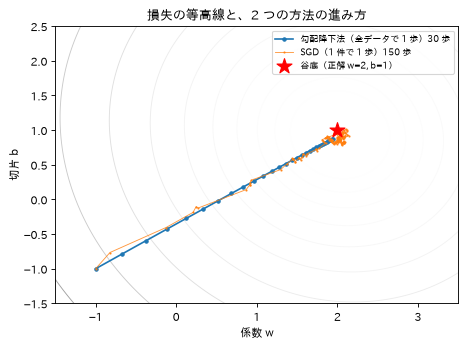

In [2]:
rng = np.random.RandomState(0)
x = rng.randn(200); y = 2.0 * x + 1.0 + 0.5 * rng.randn(200)          # 正解は w=2, b=1

def loss(w, b):
    return 0.5 * np.mean((w * x[:, None, None] + b - y[:, None, None]) ** 2, axis=0)

# 勾配降下法（毎回、全 200 件で勾配を計算）
w, b, eta = -1.0, -1.0, 0.1
gd_path = [(w, b)]
for _ in range(30):
    r = w * x + b - y
    w, b = w - eta * np.mean(r * x), b - eta * np.mean(r)
    gd_path.append((w, b))

# SGD（1 件ずつ勾配を計算して更新）
w, b, eta = -1.0, -1.0, 0.05
sgd_path = [(w, b)]
for i in rng.permutation(200)[:150]:
    r = w * x[i] + b - y[i]
    w, b = w - eta * r * x[i], b - eta * r
    sgd_path.append((w, b))

W, B = np.meshgrid(np.linspace(-1.5, 3.5, 200), np.linspace(-1.5, 2.5, 200))
plt.figure(figsize=(6.5, 4.5))
plt.contour(W, B, loss(W, B), levels=np.logspace(-1, 1.3, 15), cmap="Greys", linewidths=0.8)
gp, sp = np.array(gd_path), np.array(sgd_path)
plt.plot(gp[:, 0], gp[:, 1], "o-", ms=3, label="勾配降下法（全データで 1 歩）30 歩")
plt.plot(sp[:, 0], sp[:, 1], ".-", ms=2, lw=0.8, alpha=0.8, label="SGD（1 件で 1 歩）150 歩")
plt.scatter([2], [1], marker="*", s=200, c="red", zorder=3, label="谷底（正解 w=2, b=1）")
plt.xlabel("係数 w"); plt.ylabel("切片 b"); plt.legend(fontsize=8); plt.grid(False)
plt.title("損失の等高線と、2 つの方法の進み方"); plt.show()

### 👀 結果の読み方

- **勾配降下法**（青）は、毎回全データを使って「正確な下り方向」を計算するので、なめらかな道筋で谷底へ向かいます。ただし 1 歩ごとに 200 件分の計算が必要です。
- **SGD**（オレンジ）は、1 件のデータだけで方向を決めるので、道筋が**ギザギザ**になります。それでも全体としては谷底に向かいますが、谷底に着いてからも止まらず、そのまわりを**うろうろ**し続けます（星印の近くのオレンジの点の散らばり）。1 歩の計算は 1 件分だけなので、200 歩進んでも勾配降下法の 1 歩分の計算量です。

「1 歩は不正確だが、とても安い」というのが SGD の本質です。谷底の近くでのふらつきを抑えるのが、学習率を下げていく工夫（8 章）や、重みの平均をとる工夫（ASGD）です。

### 🧪 やってみよう: 「SGD は同じ問題を別の方法で解いているだけ」を確かめる

ガイドの言う同等性を確かめます。ただし、SGD と専用の推定器では**正則化の強さの表し方が違う**ので、換算が必要です。

### 💬 正則化の強さの換算（ことばで）

SGD の `alpha` は「1 件あたりの**平均**の損失」に対する正則化の強さです。一方、`LogisticRegression` の `C` や `Ridge` の `alpha` は「損失の**合計**」に対する強さです。そのため、同じ問題として比べるときは、サンプル数 n で換算します。

| 比べる相手 | 換算 |
|---|---|
| `LogisticRegression(C=C)` | SGD の `alpha` = 1 ÷（n × `C`） |
| `Ridge(alpha=a)` | `Ridge` の `alpha` = n × SGD の `alpha` |

> 📐 式で確かめたい人へ: [数式編「正則化の強さの換算」](./math/05_sgd_math.md#conv)

In [3]:
Xc, yc = make_classification(n_samples=1000, n_features=5, random_state=0)
Xr, yr = make_regression(n_samples=1000, n_features=5, noise=5, random_state=0)
n, C, alpha = 1000, 1.0, 0.01

lr_ref = lm.LogisticRegression(C=C, tol=1e-10, max_iter=5000).fit(Xc, yc)
ridge_ref = lm.Ridge(alpha=n * alpha).fit(Xr, yr)
rows = []
for label, kw in [("既定の停止条件（tol=1e-3）", dict()), ("収束まで回す（tol=None, 3000 エポック）", dict(tol=None, max_iter=3000))]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        s_log = lm.SGDClassifier(loss="log_loss", alpha=1 / (n * C), average=True, random_state=0, **kw).fit(Xc, yc)
        s_sq = lm.SGDRegressor(loss="squared_error", penalty="l2", alpha=alpha, average=True, random_state=0, **kw).fit(Xr, yr)
    rows.append({"条件": label,
                 "LogisticRegression との係数の差（最大）": np.abs(s_log.coef_ - lr_ref.coef_).max(), "反復回数（分類）": s_log.n_iter_,
                 "Ridge との係数の差（最大）": np.abs(s_sq.coef_ - ridge_ref.coef_).max(), "反復回数（回帰）": s_sq.n_iter_})
pd.DataFrame(rows).set_index("条件")

,LogisticRegression との係数の差（最大）,反復回数（分類）,Ridge との係数の差（最大）,反復回数（回帰）
条件,,,,
既定の停止条件（tol=1e-3）,0.4144,19,2.6702,11
"収束まで回す（tol=None, 3000 エポック）",0.0031,3000,0.0091,3000


### 👀 結果の読み方

- 十分に回せば（下の行）、`SGDClassifier(loss='log_loss')` は `LogisticRegression` と、`SGDRegressor` は `Ridge` と、係数がほぼ一致します（差は係数の大きさに比べてごくわずか）。同じ最適化問題を、別の方法で解いているからです。
- 既定の停止条件（上の行）では、はるかに少ない反復で止まり、係数のずれが大きくなります。

> ⚠️ **つまずきポイント（ガイドに書かれていない）**: SGD の損失は 1 件ずつの更新でふらつくので、「損失が `tol` 以上改善しない状態が `n_iter_no_change` 回続いたら止める」という停止条件（6 章）に早めに引っかかります。`tol` を小さくしても同じことが起こりえます。SGD の結果を専用の推定器と比べたり、精密な係数が必要だったりするときは、`tol=None` にして `max_iter` を十分に大きくし、`average=True` も使うと安定します。

---
## 1. 分類（1.5.1 Classification）

### 📖 ガイドの解説

`SGDClassifier` は、分類のためのさまざまな損失関数と正則化に対応した、素朴な確率的勾配降下法の学習ルーチンを実装しています。ほかの分類器と同じく、学習サンプルを持つ形 `(n_samples, n_features)` の配列 `X` と、クラスラベルを持つ形 `(n_samples,)` の配列 `y` の 2 つで学習します。

### 🧪 やってみよう: ガイドのコード例

In [4]:
X = [[0., 0.], [1., 1.]]
y = [0, 1]
clf = lm.SGDClassifier(loss="hinge", penalty="l2", max_iter=5, random_state=0)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")               # 5 エポックでは収束しないという警告を抑える
    clf.fit(X, y)
print("predict([[2., 2.]]) =", clf.predict([[2., 2.]]))
print("coef_ =", clf.coef_, "/ intercept_ =", clf.intercept_)
print("decision_function([[2., 2.]]) =", clf.decision_function([[2., 2.]]))
assert (clf.predict([[2., 2.]]) == [1]).all()
assert np.allclose(clf.coef_, [[9.9, 9.9]], atol=0.1) and np.allclose(clf.intercept_, [-9.9], atol=0.1)  # ガイド: 9.9, -9.9

predict([[2., 2.]]) = [1]
coef_ = [[9.9108 9.9108]] / intercept_ = [-9.97]
decision_function([[2., 2.]]) = [29.6732]


📖 SGD は学習データに**線形モデル**を当てはめます。`coef_` 属性がモデルのパラメータ、`intercept_` 属性が切片（オフセット、バイアス）です。切片を使うかどうか（バイアスのある超平面にするか）は `fit_intercept` で決めます。超平面までの**符号付きの距離**（係数と入力の内積に切片を足したもの）は、`SGDClassifier.decision_function` で得られます。

👀 ガイドの出力（`coef_ = [[9.9, 9.9]]`, `intercept_ = [-9.9]`, `decision_function = [29.6]`）とほぼ同じ値になりました。切片は乱数の種（`random_state`）によって −9.99 や −9.97 になります。SGD はデータをシャッフルするので、**実行のたびに結果が少し変わる**のが普通です。

> 📚 **用語**: **符号付きの距離** — 超平面のどちら側にあるかを符号で、どれだけ離れているかを大きさで表した量。厳密な幾何学的距離は $\lVert w \rVert$ で割った値だが、ここでは割らない値（`decision_function` の値）をそう呼んでいる。

### 📖 損失関数の選び方

`loss` 引数で損失関数を選びます。`SGDClassifier` は次の損失に対応しています。

| `loss` | 意味 |
|---|---|
| `"hinge"` | （ソフトマージンの）線形サポートベクターマシン |
| `"modified_huber"` | なめらかにしたヒンジ損失 |
| `"log_loss"` | ロジスティック回帰 |
| 回帰の損失すべて（2 章） | 目的変数を −1 か 1 に符号化して回帰問題として扱い、予測した値の符号をクラスとする |

最初の 2 つ（`hinge` と `modified_huber`）は**怠惰（lazy）**です。サンプルがマージンの制約を破ったときだけモデルのパラメータを更新するので、学習がとても効率的になり、L2 正則化を使っていても、より疎な（0 の係数が多い）モデルになることがあります。

`loss="log_loss"` または `loss="modified_huber"` を使うと、`predict_proba` メソッドが使えるようになり、サンプルごとの、各クラスの確率の推定値が得られます。

In [5]:
clf = lm.SGDClassifier(loss="log_loss", max_iter=5, random_state=0)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    clf.fit(X, y)
print("predict_proba([[1., 1.]]) =", clf.predict_proba([[1., 1.]]).round(4))
assert clf.predict_proba([[1., 1.]])[0, 1] > 0.99            # ガイド: array([[0.00, 0.99]])
for loss in ["hinge", "log_loss", "modified_huber"]:
    print(f"loss={loss!r:17} predict_proba を持つ: {hasattr(lm.SGDClassifier(loss=loss), 'predict_proba')}")

predict_proba([[1., 1.]]) = [[0.0046 0.9954]]
loss='hinge'           predict_proba を持つ: False
loss='log_loss'        predict_proba を持つ: True
loss='modified_huber'  predict_proba を持つ: True


👀 `hinge` では `predict_proba` が使えません（1.4 の SVM と同じく、ヒンジ損失は確率のモデルではないため）。

### 📖 正則化の選び方

`penalty` 引数で正則化を選びます。

| `penalty` | 意味 |
|---|---|
| `"l2"`（既定） | `coef_` の L2 ノルムの罰 |
| `"l1"` | `coef_` の L1 ノルムの罰。疎な解（ほとんどの係数が 0）になる |
| `"elasticnet"` | L2 と L1 の凸結合: `(1 - l1_ratio) * L2 + l1_ratio * L1` |

Elastic Net は、相関の強い属性があるときの L1 の欠点を解決します（1.1 の 1/4 を参照）。`l1_ratio` が L1 と L2 の組み合わせの割合を決めます。

### 📖 多クラス分類

`SGDClassifier` は、複数の 2 値分類器を「**one versus all（OVA）**」方式で組み合わせて、多クラス分類に対応します。$K$ 個のクラスのそれぞれについて、そのクラスとほかの $K - 1$ 個のクラスを見分ける 2 値分類器を学習します。予測のときは、各分類器の確信度のスコア（超平面までの符号付きの距離）を計算し、いちばん確信度の高いクラスを選びます。

多クラス分類では、`coef_` は形 `(n_classes, n_features)` の 2 次元配列、`intercept_` は形 `(n_classes,)` の 1 次元配列です。`coef_` の $i$ 行目が、$i$ 番目のクラスの OVA 分類器の重みベクトルです。クラスは昇順に並びます（`classes_` 属性を参照）。原理的には、確率のモデルを作れる `loss="log_loss"` と `loss="modified_huber"` のほうが、one-vs-all の分類に向いていることに注意してください。

> 📚 **用語**: **one versus all（OVA）** — 1.4 の one-vs-rest（ovr）と同じ。「そのクラスか、それ以外か」の分類器をクラスの数だけ作る。

#### 📈 学習したモデルを見る: ガイドの例「Plot multi-class SGD on the iris dataset」

アヤメの 2 特徴（がく片の長さと幅、標準化済み）で `SGDClassifier` を学習し、3 つの OVA 分類器それぞれの超平面（点線）と、それらが作る決定領域を描きます。

coef_ の形: (3, 2) / intercept_ の形: (3,) / classes_: [0 1 2]


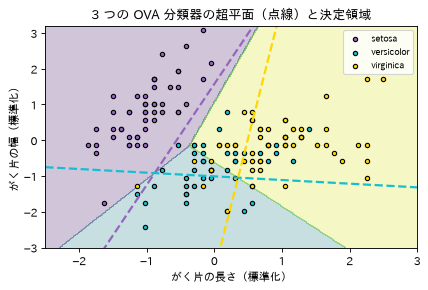

In [6]:
iris = load_iris()
Xi = StandardScaler().fit_transform(iris.data[:, :2]); yi = iris.target
sgd_i = lm.SGDClassifier(alpha=0.001, max_iter=100, random_state=0).fit(Xi, yi)
print("coef_ の形:", sgd_i.coef_.shape, "/ intercept_ の形:", sgd_i.intercept_.shape, "/ classes_:", sgd_i.classes_)

xx, yy = np.meshgrid(np.linspace(-2.5, 3, 300), np.linspace(-3, 3.2, 300))
plt.contourf(xx, yy, sgd_i.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape), alpha=0.25, cmap="viridis")
colors = ["tab:purple", "tab:cyan", "gold"]
for k in range(3):
    plt.scatter(Xi[yi == k, 0], Xi[yi == k, 1], s=15, c=colors[k], edgecolor="k", label=iris.target_names[k])
    w, b = sgd_i.coef_[k], sgd_i.intercept_[k]
    t = np.linspace(-2.5, 3, 2)
    plt.plot(t, -(w[0] * t + b) / w[1], ls="--", c=colors[k], lw=2)
plt.xlim(-2.5, 3); plt.ylim(-3, 3.2); plt.legend(fontsize=8); plt.grid(False)
plt.xlabel("がく片の長さ（標準化）"); plt.ylabel("がく片の幅（標準化）")
plt.title("3 つの OVA 分類器の超平面（点線）と決定領域"); plt.show()

### 👀 結果の読み方

- 点線は、各クラスの OVA 分類器の超平面（そのクラスの `decision_function` が 0 になる線）です。点線の片側が「そのクラスらしい」側です。
- 背景の色は、3 つの分類器のうち確信度が最も高いクラスです。決定領域の境目は、点線そのものではなく、「2 つの分類器の確信度が等しくなる線」になります。
- setosa（紫）は 1 本の点線でほぼきれいに分けられています。一方、versicolor（水色）は setosa と virginica の**間**にあるので、「versicolor かそれ以外か」を 1 本の直線では分けられません。その点線はほぼ水平で、「がく片の幅が小さい」ことしか捉えておらず、水色の決定領域は下の方の小さな三角形だけです。多くの versicolor の点が virginica（黄）の領域に入っています。これが One-vs-Rest の弱点です（がく片の 2 特徴だけでは、どの分類器でも versicolor と virginica はかなり重なります）。

### 📖 重み付けと平均化 SGD

`SGDClassifier` は、`fit` の引数 `class_weight` と `sample_weight` で、クラスの重み付けとサンプルの重み付けの両方に対応しています（1.4 の 1/2 の不均衡データの節を参照）。

`SGDClassifier` は**平均化 SGD（ASGD）**にも対応しています。`average=True` で有効になります。ASGD は通常の SGD と同じ更新をしますが、`coef_` 属性に係数の**最後の値**（最後の更新の値）を使う代わりに、**すべての更新にわたる係数の平均値**を使います。`intercept_` 属性も同様です。ASGD を使うと、学習率を大きく、さらには一定にでき、データによっては学習が速くなります（平均の計算式は 8 章）。

ロジスティック損失での分類なら、平均化の戦略を使った SGD の別の変種として、**確率的平均勾配（SAG）**アルゴリズムが `LogisticRegression` のソルバとして使えます。

> 📚 **用語**: **SAG（Stochastic Average Gradient）** — 過去に計算した各サンプルの勾配を覚えておき、その平均で更新する方法。SGD より収束が速いが、サンプル数分の勾配を記憶するメモリが要る（1.1 の 3/4 で `solver="sag"` として登場）。

---
## 2. 回帰（1.5.2 Regression）

### 📖 ガイドの解説

`SGDRegressor` は、線形回帰モデルを当てはめるための、さまざまな損失関数と正則化に対応した、素朴な確率的勾配降下法の学習ルーチンを実装しています。`SGDRegressor` は、**学習サンプルの数が多い（10,000 件を超える）**回帰問題に向いています。それ以外の問題では、`Ridge`、`Lasso`、`ElasticNet` が勧められています。

`loss` 引数で損失関数を選びます。

| `loss` | 意味 |
|---|---|
| `"squared_error"` | 最小二乗法 |
| `"huber"` | 頑健な回帰のための Huber 損失 |
| `"epsilon_insensitive"` | 線形サポートベクター回帰 |

Huber 損失と ε-不感損失は、頑健な回帰に使えます。不感領域の幅は `epsilon` 引数で指定します。**この引数は目的変数のスケールに依存します**。正則化（`penalty`）と平均化 SGD（`average`）は、分類の場合と同じです。二乗損失と L2 正則化の回帰なら、平均化の戦略を使った SGD の変種として、SAG アルゴリズムが `Ridge` のソルバとして使えます。

> ⚠️ **つまずきポイント**: 「`epsilon` は目的変数のスケールに依存する」の具体例は、1.1 の 4/4 で確かめました。`SGDRegressor(loss="huber")` は、目的変数を 100 倍すると、係数が 100 倍にならずに崩れました（`HuberRegressor` はスケール不変）。SGD で Huber 損失を使うときは、目的変数のスケールに合わせて `epsilon` を設定する必要があります。

#### 📈 学習したモデルを見る: 3 つの損失で学習した直線

外れ値を含む 1 次元のデータ（標準化済み）で、3 つの損失の `SGDRegressor` が学習した直線を比べます。

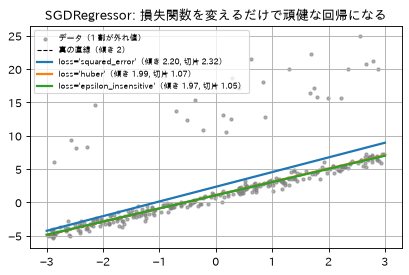

In [7]:
rng = np.random.RandomState(0)
xr = rng.uniform(-3, 3, 300); yr_ = 2 * xr + 1 + 0.5 * rng.randn(300)
yr_[:30] += rng.uniform(10, 20, 30)                    # 1 割を y 方向の大きな外れ値に
Xr1 = xr[:, None]
g = np.linspace(-3, 3, 50)[:, None]
plt.scatter(xr, yr_, s=8, c="gray", alpha=0.6, label="データ（1 割が外れ値）")
plt.plot(g, 2 * g + 1, "k--", lw=1, label="真の直線（傾き 2）")
for loss, kw in [("squared_error", {}), ("huber", dict(epsilon=1.0)), ("epsilon_insensitive", dict(epsilon=0.5))]:
    m = lm.SGDRegressor(loss=loss, max_iter=2000, tol=None, average=True, random_state=0, **kw).fit(Xr1, yr_)
    plt.plot(g, m.predict(g), lw=2, label=f"loss={loss!r}（傾き {m.coef_[0]:.2f}, 切片 {m.intercept_[0]:.2f}）")
plt.legend(fontsize=7); plt.title("SGDRegressor: 損失関数を変えるだけで頑健な回帰になる"); plt.show()

👀 二乗誤差（`squared_error`）の直線は、上にある外れ値に引っ張られて切片が持ち上がっています（真の切片 1 に対して約 2.3。傾きも少しずれます）。Huber 損失と ε-不感損失の直線は、外れ値の影響を抑えて真の直線に近くなっています（2 本はほぼ重なっていて、オレンジの線は緑の線の下に隠れています）。同じ `SGDRegressor` でも、**損失関数の引数 1 つで別のモデルになる**ことが分かります。

---
## 3. オンライン One-Class SVM（1.5.3 Online One-Class SVM）

### 📖 ガイドの解説

`sklearn.linear_model.SGDOneClassSVM` は、確率的勾配降下法を使って、One-Class SVM のオンラインの線形版を実装しています。**カーネル近似**の手法と組み合わせると、`SGDOneClassSVM` は、`sklearn.svm.OneClassSVM` で実装されているカーネルの One-Class SVM の解を、サンプル数に対して**線形の計算量**で近似できます。カーネルの One-Class SVM の計算量は、最も良い場合でもサンプル数の 2 乗です。そのため `SGDOneClassSVM` は、学習サンプルが多い（10,000 件を超える）データに向いていて、SGD 版が何桁も速くなることがあります。

> 📚 **用語**
> - **カーネル近似**: カーネル（RBF など）の計算を、有限個の特徴への変換で近似する手法（6.7 節）。`Nystroem` は、学習データの一部を使ってその変換を作る方法。変換後は線形モデルで扱えるので、SGD が使える。
> - **オンライン**: データを 1 件（または少し）ずつ受け取りながら学習できること。

### 📖 しくみ

One-Class SVM は、「正常なデータのほとんどが『正常らしさのスコア ≥ しきい値』になるように、なるべく単純なスコアと高いしきい値を探す」問題です。はみ出してよい割合の目安が `nu` です。この問題は、式を変形すると「すべてのサンプルの正解が『正常（+1）』のヒンジ損失の分類」とほぼ同じ形になるので、`SGDClassifier` と同じ仕組み（8 章）で解けます。`average=True` で平均化 SGD も使えます。

> 📐 式で確かめたい人へ: [数式編「One-Class SVM の最適化問題」](./math/05_sgd_math.md#ocsvm)

### 🧪 やってみよう / 📈: カーネルの One-Class SVM と SGD 版の比較

ガイドの例「One-Class SVM versus One-Class SVM using Stochastic Gradient Descent」と同じく、`Nystroem`（カーネル近似）と `SGDOneClassSVM` を組み合わせ、`OneClassSVM`（RBF カーネル）と比べます。サンプル数を増やしたときの学習時間と、学習した境界を見ます。

In [8]:
from sklearn.kernel_approximation import Nystroem

def make_ocsvm_data(n, seed=0):
    r = np.random.RandomState(seed)
    return np.r_[0.3 * r.randn(n // 2, 2) + 2, 0.3 * r.randn(n // 2, 2) - 2]

def make_models():
    return {"OneClassSVM（RBF カーネル）": svm.OneClassSVM(nu=0.05, gamma=2),
            "Nystroem + SGDOneClassSVM": make_pipeline(Nystroem(gamma=2, n_components=150, random_state=0),
                                                       lm.SGDOneClassSVM(nu=0.05, tol=1e-4, random_state=0))}

rows = []
for n in [5000, 10000, 20000, 40000]:
    Xo = make_ocsvm_data(n)
    preds = {}
    for name, m in make_models().items():
        t = time.perf_counter(); m.fit(Xo); dt = time.perf_counter() - t
        preds[name] = m.predict(Xo)
        rows.append({"サンプル数": n, "モデル": name, "学習時間（秒）": dt, "外れ値とした割合": (preds[name] == -1).mean()})
    rows[-1]["2 つの予測の一致率"] = (preds["OneClassSVM（RBF カーネル）"] == preds["Nystroem + SGDOneClassSVM"]).mean()
df_oc = pd.DataFrame(rows)
df_oc.pivot(index="サンプル数", columns="モデル", values="学習時間（秒）")

モデル,Nystroem + SGDOneClassSVM,OneClassSVM（RBF カーネル）
サンプル数,,
5000,0.0229,0.0446
10000,0.0361,0.1828
20000,0.1127,0.7627
40000,0.1479,3.9029


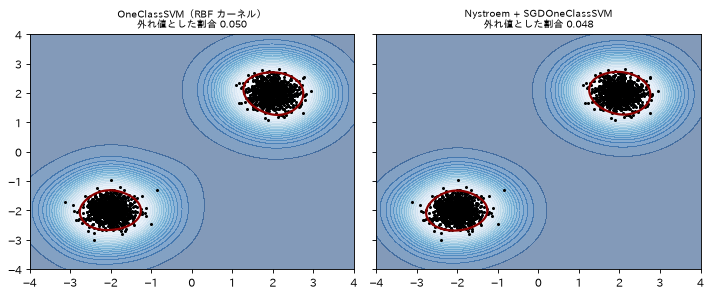

学習時間の表に対応する予測の一致率:


,2 つの予測の一致率
サンプル数,
5000,0.9934
10000,0.9921
20000,0.9963
40000,0.9973


In [9]:
Xo = make_ocsvm_data(2000)
xx, yy = np.meshgrid(np.linspace(-4, 4, 200), np.linspace(-4, 4, 200))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, (name, m) in zip(axes, make_models().items()):
    m.fit(Xo)
    Z = m.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="Blues_r", alpha=0.5)
    ax.contour(xx, yy, Z, levels=[0], colors="darkred", linewidths=2)
    ax.scatter(Xo[:, 0], Xo[:, 1], s=3, c="k")
    ax.set_title(f"{name}\n外れ値とした割合 {(m.predict(Xo) == -1).mean():.3f}", fontsize=9); ax.grid(False)
plt.tight_layout(); plt.show()
print("学習時間の表に対応する予測の一致率:")
df_oc.dropna()[["サンプル数", "2 つの予測の一致率"]].set_index("サンプル数")

### 👀 結果の読み方

- **学習時間**: 5,000 件程度ではどちらも 0.1 秒未満で、差は気になりません。サンプル数が 2 倍になるごとに `OneClassSVM` の時間は 4〜5 倍（2 乗以上の勢い）で増え、4 万件では SGD 版のほうが 1 桁以上速くなりました。SGD 版はほぼ線形にしか増えません。ガイドの「10,000 件を超えるデータで、SGD 版が何桁も速くなることがある」は、データが大きいほど当てはまります。
- **学習した境界**（図）: 2 つの集まりのまわりに、ほぼ同じ形の境界（濃い赤の線）を学習しています。予測の一致率も 99% 以上です。
- `nu=0.05` に対して、外れ値とした割合はどちらも 0.05 前後です。

---
## 4. 疎なデータの SGD（1.5.4 Stochastic Gradient Descent for sparse data）

### 📖 ガイドの解説

> 📖 **ノート**: 疎なデータの実装は、**切片の学習率を小さくしている**ため、密なデータの実装とは少し違う結果になります（9 章の実装の詳細を参照）。

`scipy.sparse` が対応している形式の行列なら、疎なデータに標準で対応しています。ただし最も効率が良いのは、`scipy.sparse.csr_matrix` で定義される **CSR 行列**の形式です。

> 📚 **用語**: **CSR（Compressed Sparse Row）形式** — 疎な行列を、行ごとに「0 でない値」と「その列番号」だけを並べて保存する形式。行を順に取り出すのが速いので、1 件（1 行）ずつ処理する SGD に向いている。

### 🧪 やってみよう: 同じデータを密と疎で学習する

In [10]:
Xs, ys = make_classification(n_samples=500, n_features=20, random_state=0)
dense_m = lm.SGDClassifier(random_state=0).fit(Xs, ys)
sparse_m = lm.SGDClassifier(random_state=0).fit(sparse.csr_matrix(Xs), ys)
pd.DataFrame({"密（numpy.ndarray）": [dense_m.intercept_[0], np.abs(dense_m.coef_).mean(), dense_m.score(Xs, ys)],
              "疎（csr_matrix）": [sparse_m.intercept_[0], np.abs(sparse_m.coef_).mean(), sparse_m.score(Xs, ys)]},
             index=["intercept_", "|coef_| の平均", "学習データの正解率"])

,密（numpy.ndarray）,疎（csr_matrix）
intercept_,1.3290,0.4839
|coef_| の平均,0.8773,0.9000
学習データの正解率,0.7240,0.7500


👀 中身はまったく同じデータなのに、疎な形式で渡すと切片（`intercept_`）が大きく違う値になりました。係数や正解率も少し変わります。9 章で説明するように、疎なデータでは切片の学習率を 0.01 倍にしているためです。

> ⚠️ **つまずきポイント**: 「このデータは 0 が多くないから」と密な行列に変換したり、逆に疎な行列に変換したりすると、SGD の結果が変わることがあります。比較実験では、データの形式もそろえておきましょう。

---
## 5. 計算量（1.5.5 Complexity）

### 📖 ガイドの解説

SGD の最大の利点は効率で、学習データの数に対して基本的に**線形**です。学習のコストは「**エポック数 × サンプル数 × 1 サンプルあたりの 0 でない特徴の数**」に比例します（記号では $O(k n \bar{p})$）。

ただし最近の理論的な結果によると、ある最適化の精度を得るのに必要な実行時間は、**学習データが増えても増えません**。

💬 **ことばで言うと**: 1 件の更新には、その件の 0 でない特徴の数だけ計算が要る。それをサンプルの数だけ、エポックの数だけ繰り返す。文書のデータのように、特徴が数十万あっても 1 文書に出る単語が数百なら、1 件あたりの計算は数百で済む。

> 📐 式で確かめたい人へ: [数式編「SGD の計算量」](./math/05_sgd_math.md#complexity)

💡 「データが増えても必要な実行時間は増えない」とは、データが多ければ、**1 周する前に**十分な精度に達するので、全部を見る必要がない、という意味です。7 章の「約 100 万件（$10^6$ 件）見れば収束する」という経験則とも関係します。

### 🧪 やってみよう / 📈: サンプル数による学習時間

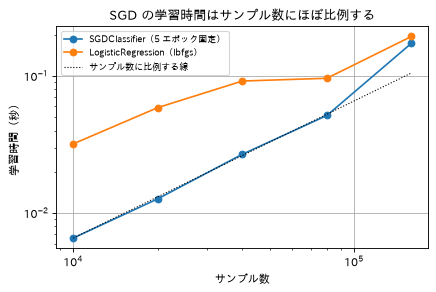

,SGDClassifier（5 エポック固定）,LogisticRegression（lbfgs）
サンプル数,,
10000,0.0066,0.0320
20000,0.0127,0.0588
40000,0.0269,0.0919
80000,0.0515,0.0962
160000,0.1732,0.1942


In [11]:
records = []
for n in [10_000, 20_000, 40_000, 80_000, 160_000]:
    Xn, yn = make_classification(n_samples=n, n_features=50, random_state=0)
    records.append({"サンプル数": n,
                    "SGDClassifier（5 エポック固定）": best_time(lambda: lm.SGDClassifier(max_iter=5, tol=None, random_state=0).fit(Xn, yn)),
                    "LogisticRegression（lbfgs）": best_time(lambda: lm.LogisticRegression(max_iter=1000).fit(Xn, yn))})
df_t = pd.DataFrame(records).set_index("サンプル数")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    df_t.plot(loglog=True, marker="o")
plt.plot(df_t.index, df_t.iloc[0, 0] * df_t.index / df_t.index[0], "k:", lw=1, label="サンプル数に比例する線")
plt.legend(fontsize=8); plt.ylabel("学習時間（秒）"); plt.title("SGD の学習時間はサンプル数にほぼ比例する"); plt.show()
df_t

👀 SGD（エポック数を固定）の学習時間は、点線（サンプル数に比例する線）とおおむね平行に増えています。サンプル数が 2 倍なら時間も約 2 倍、という線形の関係です（細かい値は実行環境やその時の負荷で前後します）。

一方、`LogisticRegression`（lbfgs）も、この規模では SGD と同じ桁の時間で終わり、16 万件では同程度でした。つまり、**「SGD のほうが常に速い」わけではありません**。このデータは簡単な問題で、lbfgs は 6〜9 回の反復（1 回の反復で全データを 1 回なめる）で収束したので、lbfgs の時間もほぼサンプル数に比例しています（増え方が少し不規則なのは、データによって反復回数が 6〜9 回と変わるためです）。

> ⚠️ **つまずきポイント（ガイドに書かれていない）**: SGD の本当の強みは、「メモリに載る中くらいのデータで専用ソルバより速い」ことではなく、(1) 1 エポックの計算量がサンプル数に比例し、データが多ければ 1 周する前に十分な精度に達すること、(2) `partial_fit` でメモリに載らないデータや流れてくるデータを少しずつ学習できること、(3) テキスト分類のような、特徴の数が非常に多い疎なデータでも扱いやすいことです。中くらいの大きさの密なデータなら、まず専用の推定器（`LogisticRegression` や `Ridge`）を試すのが無難です。

---
## 6. 停止の基準（1.5.6 Stopping criterion）

### 📖 ガイドの解説

`SGDClassifier` と `SGDRegressor` には、ある水準の収束に達したときにアルゴリズムを止めるための 2 つの基準があります。

- **`early_stopping=True`**: 入力データを学習用と**検証用**に分けます。モデルは学習用のデータで学習し、停止の基準には、検証用のデータで計算した予測のスコア（`score` メソッド）を使います。検証用のデータの大きさは `validation_fraction` で変えられます。
- **`early_stopping=False`**: モデルは入力データ全体で学習し、停止の基準には、学習データで計算した**目的関数**を使います。

どちらの場合も、基準はエポックごとに 1 回評価され、基準が `n_iter_no_change` 回続けて改善しなかったときに止まります。改善は絶対的な許容誤差 `tol` で評価され、いずれにしても最大の反復回数 `max_iter` に達すれば止まります。

> 📚 **用語**
> - **早期停止（early stopping）**: 見ていないデータ（検証データ）での成績が良くならなくなった時点で学習を止める方法。過学習を防ぐ効果もある。
> - **検証データ（validation set）**: 学習には使わず、学習の途中の成績を測るために取っておくデータ。最終評価に使うテストデータとは別に用意する。

### 🧪 やってみよう

In [12]:
Xe, ye = make_classification(n_samples=20000, n_features=20, n_informative=5, flip_y=0.1, random_state=0)
Xe_tr, Xe_te, ye_tr, ye_te = train_test_split(Xe, ye, random_state=0)
rows = []
for es in [False, True]:
    m = lm.SGDClassifier(early_stopping=es, random_state=0).fit(Xe_tr, ye_tr)
    rows.append({"early_stopping": es, "止まるまでのエポック数 n_iter_": m.n_iter_, "テストの正解率": m.score(Xe_te, ye_te)})
pd.DataFrame(rows).set_index("early_stopping")

,止まるまでのエポック数 n_iter_,テストの正解率
early_stopping,,
False,93,0.8888
True,12,0.8798


👀 `early_stopping=True` では、検証データのスコアが改善しなくなった時点で早めに止まり、エポック数が少なくなりました。それでもテストの正解率は同程度です。データが大きいときは、無駄な計算を省けます。

---
## 7. 実践のコツ（1.5.7 Tips on Practical Use）

### 📖 ガイドの解説

**① スケーリング**: SGD は特徴のスケーリングに敏感なので、データのスケーリングを強く勧めます。たとえば入力ベクトル $X$ の各属性を $[0, 1]$ や $[-1, 1]$ にスケーリングするか、平均 0・分散 1 に標準化します。テストのベクトルにも**同じスケーリング**を適用しないと、意味のある結果になりません。これは `StandardScaler` で簡単にできます（学習データだけで `fit` する。テストデータで `fit` するのは「ずる」）。もっと良いのは、パイプラインを使うことです。属性にもともと決まったスケールがある場合（単語の頻度や、0 / 1 の指標の特徴など）は、スケーリングは不要です。

**② 正則化の強さ**: 妥当な正則化の項 $\alpha$ を見つけるには、`GridSearchCV` や `RandomizedSearchCV` による自動のハイパーパラメータ探索が最適で、範囲は通常 `10.0**-np.arange(1,7)` です。

**③ 反復回数**: 経験的に、SGD は**約 $10^6$ 件の学習サンプルを見たあとに収束**します。そのため、反復回数の最初の目安は `max_iter = np.ceil(10**6 / n)`（`n` は学習データの大きさ）です。

**④ PCA の特徴**: PCA で抽出した特徴に SGD を使うなら、学習データの L2 ノルムの平均が 1 になるように、特徴の値を定数 $c$ で割るのが賢明なことが多い、とされています。

**⑤ 平均化 SGD**: 平均化 SGD は、特徴の数が多く、`eta0` が大きいときに最もよく働くことが分かっています。

### 🧪 やってみよう ①: スケーリングの効果

In [13]:
Xs7, ys7 = make_classification(n_samples=2000, n_features=10, n_informative=5, random_state=0)
Xs7_bad = Xs7 * np.r_[np.ones(5), np.full(5, 100.0)]              # 後半 5 個の特徴を 100 倍
Xa, Xb_, ya, yb_ = train_test_split(Xs7_bad, ys7, random_state=0)
pd.DataFrame({"テストの正解率": [lm.SGDClassifier(random_state=0).fit(Xa, ya).score(Xb_, yb_),
                          make_pipeline(StandardScaler(), lm.SGDClassifier(random_state=0)).fit(Xa, ya).score(Xb_, yb_)]},
             index=["スケーリングなし", "make_pipeline(StandardScaler(), SGDClassifier())"])

,テストの正解率
スケーリングなし,0.730
"make_pipeline(StandardScaler(), SGDClassifier())",0.816


👀 一部の特徴のスケールが大きいだけで、SGD の性能は大きく落ちます。スケールの大きい特徴の勾配が大きくなり、更新がその特徴に振り回されるからです。

### 🧪 やってみよう ②: ガイドの範囲で `alpha` を探す

In [14]:
pipe = make_pipeline(StandardScaler(), lm.SGDClassifier(random_state=0))
search = GridSearchCV(pipe, {"sgdclassifier__alpha": 10.0 ** -np.arange(1, 7)}, cv=5).fit(Xa, ya)
res = pd.DataFrame({"alpha": search.cv_results_["param_sgdclassifier__alpha"].data,
                    "交差検証の正解率": search.cv_results_["mean_test_score"]}).set_index("alpha")
print("ガイドの範囲 10.0**-np.arange(1,7) =", [f"{a:g}" for a in 10.0 ** -np.arange(1, 7)])
print("選ばれた alpha:", search.best_params_["sgdclassifier__alpha"])
res

ガイドの範囲 10.0**-np.arange(1,7) = ['0.1', '0.01', '0.001', '0.0001', '1e-05', '1e-06']
選ばれた alpha: 0.001


,交差検証の正解率
alpha,
1.0000e-01,0.8447
1.0000e-02,0.8487
1.0000e-03,0.8567
1.0000e-04,0.8027
1.0000e-05,0.7880
1.0000e-06,0.7753


👀 このデータでは `alpha=0.001` が最もよく、それより小さくする（正則化を弱める）と正解率が下がりました。最適な `alpha` はデータによって変わるので、ガイドのように桁ごとに探すのが定石です。

💡 パイプラインの中の推定器の引数は、`ステップ名__引数名`（アンダースコア 2 つ）で指定します。`make_pipeline` は、クラス名を小文字にしたものをステップ名にします（8.1 節）。

### 🧪 やってみよう ③ / 📈: 「約 $10^6$ 件で収束」を確かめる

1 万件の学習データを `partial_fit` で 1 エポックずつ学習し、見たサンプル数の合計（エポック数 × 1 万）とテストの正解率の関係を描きます。ガイドの目安では、`max_iter = ceil(10**6 / 10000) = 100` エポックです。

ガイドの目安 max_iter = 100


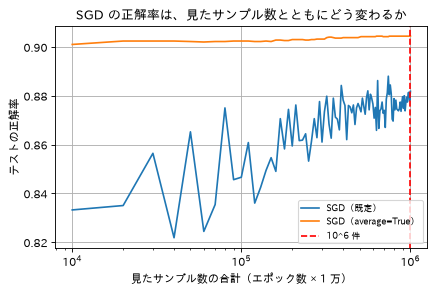

,SGD（既定）,SGD（average=True）
見たサンプル数,,
"10,000 件",0.8332,0.9010
"50,000 件",0.8652,0.9022
"100,000 件",0.8466,0.9024
"500,000 件",0.8752,0.9040
"1,000,000 件",0.8818,0.9044


In [15]:
Xe_tr2, ye_tr2 = Xe_tr[:10000], ye_tr[:10000]
print("ガイドの目安 max_iter =", int(np.ceil(10 ** 6 / len(Xe_tr2))))
curves = {}
for label, kw in [("SGD（既定）", {}), ("SGD（average=True）", dict(average=True))]:
    s = lm.SGDClassifier(random_state=0, **kw)
    acc = []
    for ep in range(100):
        s.partial_fit(Xe_tr2, ye_tr2, classes=[0, 1])
        acc.append(s.score(Xe_te, ye_te))
    curves[label] = acc
seen = np.arange(1, 101) * len(Xe_tr2)
for label, acc in curves.items():
    plt.semilogx(seen, acc, label=label)
plt.axvline(1e6, color="red", ls="--", label="10^6 件")
plt.xlabel("見たサンプル数の合計（エポック数 × 1 万）"); plt.ylabel("テストの正解率")
plt.legend(fontsize=8); plt.title("SGD の正解率は、見たサンプル数とともにどう変わるか"); plt.show()
pd.DataFrame({k: [v[i] for i in [0, 4, 9, 49, 99]] for k, v in curves.items()},
             index=[f"{(i + 1) * 10000:,} 件" for i in [0, 4, 9, 49, 99]]).rename_axis("見たサンプル数")

### 👀 結果の読み方

- 既定の SGD（青）は、正解率が上下に大きく揺れながら、見たサンプル数が増えるにつれて少しずつ上がります。$10^6$ 件付近では揺れの幅が小さくなってきますが、まだ完全には止まっていません。ガイドの「約 $10^6$ 件で収束」は、揺れがおおむね落ち着くまでの**大まかな目安**と考えるとよいでしょう。
- 平均化 SGD（オレンジ）は、最初の 1 万件の時点で既定の SGD の 100 エポック後よりも高い正解率に達し、揺れもほとんどありません。重みの平均をとることで、1 件ごとのふらつきが打ち消されるからです。

---
## 8. しくみ（1.5.8 Mathematical formulation）

（この章の式・記号の表は数式編にあります。本文は言葉と図で説明します。）

### 📖 ガイドの解説

SGD が学習するのは「**線形のスコア**（係数 × 特徴 の合計 + 切片）」です。2 値分類では、スコアの符号（プラスかマイナスか）でクラスを決めます。係数は、

> **1 件あたりの平均の損失** + `alpha` × **正則化の罰**

を最小にするように決めます。損失（`loss`）で「外れ具合の測り方」を、正則化（`penalty`）で「係数の複雑さの罰」を選ぶと、ロジスティック回帰にも SVM にも Ridge にもなります。

> 📐 式で確かめたい人へ: [数式編「SGD が最小化するもの」](./math/05_sgd_math.md#objective)

### 📖 損失関数の詳細（Loss functions details）

| 名前 | ことばで言うと | 同等のモデル |
|---|---|---|
| ヒンジ（ソフトマージン） | 正しい側に「余裕（マージン）」を持って入っていなければ、足りない分を罰する | サポートベクター分類 |
| パーセプトロン | 間違えたときだけ、間違えた深さを罰する | パーセプトロン |
| 修正 Huber | ヒンジの 2 乗。ただし大きく間違えたところは直線にして、外れ値の影響を抑える | — |
| 対数損失 | 正解の確率が低いほど罰する（どこでも 0 にはならない） | ロジスティック回帰 |
| 二乗誤差 | ずれの 2 乗 | 線形回帰（正則化によって Ridge や Lasso） |
| Huber | 小さなずれは 2 乗、大きなずれは直線 | 頑健な回帰 |
| ε-不感 | ε 以内のずれは無視し、超えた分を直線で罰する | サポートベクター回帰 |

> 📐 式で確かめたい人へ: [数式編「損失関数の式」](./math/05_sgd_math.md#losses)

上のすべての損失関数は、ガイドの図のように、**誤分類の誤差（0-1 損失）の上界**とみなせます。

> 📚 **用語**: **上界（upper bound）** — いつもそれ以上になる値。損失関数が 0-1 損失の上界なら、損失を小さくすれば、誤分類の数も必ず小さく抑えられる。0-1 損失そのものは階段状で微分できず最適化しにくいので、代わりに滑らかな（または凸な）上界を最小化する。

#### 📈 ガイドの図の再現: 分類の損失関数

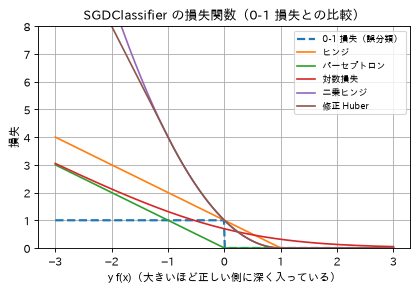

In [16]:
m_ = np.linspace(-3, 3, 400)                            # m = y f(x)
losses = {
    "0-1 損失（誤分類）": (m_ <= 0).astype(float),
    "ヒンジ": np.maximum(0, 1 - m_),
    "パーセプトロン": np.maximum(0, -m_),
    "対数損失": np.log(1 + np.exp(-m_)),
    "二乗ヒンジ": np.maximum(0, 1 - m_) ** 2,
    "修正 Huber": np.where(m_ > -1, np.maximum(0, 1 - m_) ** 2, -4 * m_),
}
for name, v in losses.items():
    plt.plot(m_, v, lw=2 if name.startswith("0-1") else 1.5, ls="-" if not name.startswith("0-1") else "--", label=name)
plt.ylim(0, 8); plt.xlabel("y f(x)（大きいほど正しい側に深く入っている）"); plt.ylabel("損失")
plt.legend(fontsize=8); plt.title("SGDClassifier の損失関数（0-1 損失との比較）"); plt.show()

👀 ヒンジ・二乗ヒンジ・修正 Huber は、どこでも 0-1 損失（点線の階段）以上の値をとり、0-1 損失を**上から抑えて**います。さらにマージンの内側（横軸が 0〜1 の範囲。正しく分類できているが自信がない）でも罰を与えます。例外が 2 つあります。

- パーセプトロン損失は、横軸が −1〜0 の範囲（少しだけ間違えた）で 0-1 損失（そこで 1）を下回ります。正しく分類できれば（横軸が 0 より大きい）罰はゼロで、マージン（余裕）の考え方はありません。
- 対数損失は、横軸 0 での値が約 0.69 で、1 を少し下回ります（log の底を 2 にすれば、ちょうど 0-1 損失を上から抑えます。数式編を参照）。

修正 Huber は、横軸が −1 より小さい（大きく間違えた）ところで 2 乗から直線に切り替わるので、大きく外れた点（外れ値）の影響を抑えられます。

### 📖 正則化の項

正則化の項 $R$（`penalty` 引数）の代表的な選び方は次のとおりです。

| 正則化 | ことばで言うと | 性質 |
|---|---|---|
| L2 ノルム（`"l2"`） | 係数の 2 乗の合計の半分 | — |
| L1 ノルム（`"l1"`） | 係数の絶対値の合計 | 疎な解になる |
| Elastic Net（`"elasticnet"`） | L2 と L1 を混ぜたもの | 混ぜる割合は `l1_ratio` |

> 📐 式で確かめたい人へ: [数式編「正則化の項」](./math/05_sgd_math.md#reg)



#### 📈 ガイドの図の再現: 正則化の等高線

係数が 2 つの場合に、「罰の大きさがちょうど 1」になる係数の組を描きます（罰の等高線）。

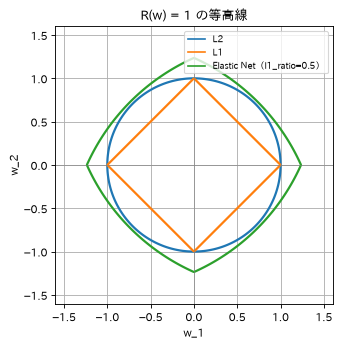

In [17]:
w1, w2 = np.meshgrid(np.linspace(-1.6, 1.6, 400), np.linspace(-1.6, 1.6, 400))
regs = {"L2": 0.5 * (w1 ** 2 + w2 ** 2) / 0.5,                 # ½||w||² を ½ で割り、半径 1 の円にそろえる
        "L1": np.abs(w1) + np.abs(w2),
        "Elastic Net（l1_ratio=0.5）": 0.5 * 0.5 * (w1 ** 2 + w2 ** 2) + 0.5 * (np.abs(w1) + np.abs(w2))}
plt.figure(figsize=(4.8, 4.5))
for (name, R), c in zip(regs.items(), ["tab:blue", "tab:orange", "tab:green"]):
    cs = plt.contour(w1, w2, R, levels=[1], colors=c, linewidths=2)
    plt.plot([], [], c=c, label=name)
plt.axhline(0, color="gray", lw=0.5); plt.axvline(0, color="gray", lw=0.5)
plt.gca().set_aspect("equal"); plt.xlabel("w_1"); plt.ylabel("w_2"); plt.legend(fontsize=8)
plt.title("R(w) = 1 の等高線"); plt.show()

👀 L2 は円、L1 はひし形です。Elastic Net は、L1 の**軸の上の尖った角を残したまま**、辺が円のように外側へふくらんだ形になります（この図では大きさをそろえていないので、形だけを見てください）。角が残るので、Elastic Net も疎な解を作れます。L1 のひし形には軸の上に**尖った角**があり、損失関数の等高線が最初にこの角に触れやすいので、片方の係数がちょうど 0 になりやすい（疎な解）、という 1.1 の 1/4 の説明の図形的な理由です。

### 1.5.8.1 SGD

📖 確率的勾配降下法は、制約のない最適化問題のための最適化の手法です。（バッチ）勾配降下法と違い、SGD は、一度に 1 つの学習データだけを考えて、$E(w, b)$ の本当の勾配を**近似**します。

`SGDClassifier` は、1 次の SGD（勾配だけを使う方法）を実装しています。学習データを順に見ていき、1 件見るたびに、

> 新しい係数 = 今の係数 − 学習率 ×（係数を小さくする向きの力 + この 1 件の損失を減らす向きの力）

という更新をします。**学習率**は 1 歩の大きさです。切片も同じように更新しますが、正則化はかけません（疎なデータの場合は、9 章で説明する追加の工夫があります）。

💬 **ことばで言うと**: 1 件見るたびに、「この 1 件の外れを減らす向き」と「係数を小さくする向き」を合わせた方向へ、学習率の分だけ係数を動かす。

> 📐 式で確かめたい人へ: [数式編「更新式」](./math/05_sgd_math.md#update)

### 🧪 やってみよう: 更新式を自分で書いて、`SGDRegressor` と照合する

（数式編と対応する実験です。とばしても先へ進めます）

二乗誤差・正則化なし・一定の学習率で、データの順番どおり（`shuffle=False`）に 1 エポックだけ学習します。上の更新式を自分で書いた結果と比べます。

In [18]:
Xm, ym = make_regression(n_samples=50, n_features=3, noise=1, random_state=1)
eta = 0.01
w, b = np.zeros(3), 0.0
w_history, b_history = [], []
for xi, yi in zip(Xm, ym):
    grad = (w @ xi + b) - yi                  # ∂L/∂f（二乗誤差 ½(y - f)² の微分）
    w = w - eta * grad * xi                   # w ← w − η ∂L/∂w
    b = b - eta * grad                        # b ← b − η ∂L/∂b（正則化なし）
    w_history.append(w.copy()); b_history.append(b)

sk = lm.SGDRegressor(loss="squared_error", penalty=None, learning_rate="constant", eta0=eta,
                     shuffle=False, max_iter=1, tol=None).fit(Xm, ym)
print("自分で書いた更新: w =", w.round(4), " b =", round(b, 4))
print("SGDRegressor     : w =", sk.coef_.round(4), " b =", sk.intercept_.round(4))
print("一致:", np.allclose(w, sk.coef_) and np.isclose(b, sk.intercept_[0]), "/ 更新回数の属性 t_ =", sk.t_)

自分で書いた更新: w = [11.6703  9.6176 22.2835]  b = 3.6111
SGDRegressor     : w = [11.6703  9.6176 22.2835]  b = [3.6111]
一致: True / 更新回数の属性 t_ = 51.0


👀 自分で書いた 6 行の更新ループと、`SGDRegressor` の結果がぴったり一致しました。SGD の中身は、本当にこの更新式の繰り返しです。`t_` は更新の回数（ここでは 50 件 + 1）を表す属性です。

### 📖 学習率のスケジュール

学習率 $\eta$ は、一定にすることも、徐々に小さくすることもできます。

| `learning_rate` | ことばで言うと | 既定で使うクラス |
|---|---|---|
| `"optimal"` | 更新の回数に反比例して小さくする（はじめの大きさは `alpha` などから自動で決まる） | `SGDClassifier` |
| `"invscaling"` | `eta0` から始めて、回数の `power_t` 乗に反比例して、ゆっくり小さくする | `SGDRegressor` |
| `"constant"` | ずっと `eta0` のまま | — |
| `"adaptive"` | `eta0` から始め、改善が止まるたびに 5 で割る。とても小さくなったら止まる | — |

> 📐 式で確かめたい人へ: [数式編「学習率のスケジュール」](./math/05_sgd_math.md#lr)

### 💬 ことばで言うと

はじめは大きな歩幅で谷底の近くまで素早く進み、時間がたつにつれて歩幅を小さくして、谷底のまわりのふらつきを抑える。`optimal` は回数に反比例して、`invscaling` はそれよりゆっくり小さくなる（`power_t` が小さいほどゆっくり）。

💡 「optimal」の減らし方は、強い凸性を持つ問題で理論的に良いとされる減らし方です。$\alpha$ が小さい（正則化が弱い）と最初の歩幅が非常に大きくなるので、ガイドが言うように、学習データのノルムがおよそ 1 になるようにスケーリングしておくことが前提になっています（7 章の ①）。

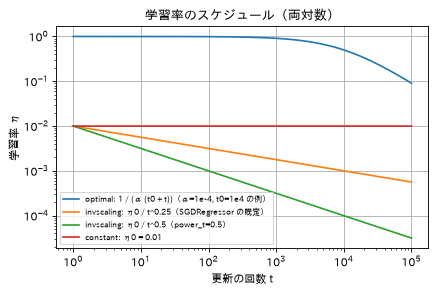

In [19]:
t = np.arange(1, 100_001)
alpha_, t0 = 1e-4, 1e4                                  # t0 は説明のための例（実際は経験則で自動決定）
schedules = {"optimal: 1 / (α (t0 + t))（α=1e-4, t0=1e4 の例）": 1 / (alpha_ * (t0 + t)),
             "invscaling: η0 / t^0.25（SGDRegressor の既定）": 0.01 / t ** 0.25,
             "invscaling: η0 / t^0.5（power_t=0.5）": 0.01 / t ** 0.5,
             "constant: η0 = 0.01": np.full(len(t), 0.01)}
for name, eta_t in schedules.items():
    plt.loglog(t, eta_t, label=name)
plt.xlabel("更新の回数 t"); plt.ylabel("学習率 η"); plt.legend(fontsize=7)
plt.title("学習率のスケジュール（両対数）"); plt.show()

👀 両対数グラフ（縦も横も 10 倍ごとに同じ間隔の目盛り）では、「回数の何乗かに反比例」するスケジュールは直線になります。`optimal` は最初は一定に近く、その後は傾き −1（回数が 10 倍になると学習率が 1/10）で急に小さくなります。`invscaling`（`power_t=0.25`）はゆっくり小さくなり、`constant` は水平です。

### 📖 平均化 SGD の係数

モデルのパラメータには、`coef_`（重み $w$）と `intercept_`（$b$）属性でアクセスできます。平均化 SGD（`average` 引数）を使うと、`coef_` は全更新にわたる重みの**平均**になります。

つまり、毎回の更新のあとの係数を全部足して、更新の回数（`t_` 属性）で割ったものです。

> 📐 式で確かめたい人へ: [数式編「平均化 SGD」](./math/05_sgd_math.md#average)

### 🧪 やってみよう: 平均化の係数を自分で計算する

上で記録しておいた、各更新**後**の重みの平均を計算し、`average=True` の `SGDRegressor` と比べます。

In [20]:
sk_avg = lm.SGDRegressor(loss="squared_error", penalty=None, learning_rate="constant", eta0=eta,
                         shuffle=False, max_iter=1, tol=None, average=True).fit(Xm, ym)
print("各更新後の重みの平均: w =", np.mean(w_history, axis=0).round(4), " b =", round(np.mean(b_history), 4))
print("SGDRegressor(average=True): w =", sk_avg.coef_.round(4), " b =", sk_avg.intercept_.round(4))
print("一致:", np.allclose(np.mean(w_history, axis=0), sk_avg.coef_) and np.isclose(np.mean(b_history), sk_avg.intercept_[0]))

各更新後の重みの平均: w = [ 5.8634  3.5578 12.8944]  b = 2.9307
SGDRegressor(average=True): w = [ 5.8634  3.5578 12.8944]  b = [2.9307]
一致: True


👀 一致しました。`average=True` の係数は、本当に「各更新のあとの重み」の単純な平均でした（この設定では、最初の重み 0 は平均に含まれず、50 回の更新後の重みの平均になっています）。

---
## 9. 実装の詳細（1.5.9 Implementation details）

### 📖 ガイドの解説

SGD の実装は、**ボトゥ**の Stochastic Gradient SVM（SvmSGD）の影響を受けています。

- SvmSGD と同じく、重みベクトルを**スカラーとベクトルの積**で表します。これにより、L2 正則化の場合に重みを効率よく更新できます。
- 疎な入力 `X` の場合、切片は、より頻繁に更新されることを考慮して、**より小さな学習率（0.01 倍）**で更新されます。
- 学習データは順番に取り出され、データを 1 件見るたびに学習率を下げます。学習率のスケジュールは **Pegasos**（Shalev-Shwartz ら, 2007）から採用しています。
- 多クラス分類には「one versus all」方式を使います。
- L1 正則化（と Elastic Net）には、**鶴岡ら**（2009）が提案した **truncated gradient（打ち切り勾配）**のアルゴリズムを使います。
- コードは Cython で書かれています。

### 💡 補足: 「スカラーとベクトルの積」の工夫

L2 正則化の更新では、毎回**係数全体に同じ数（1 より少し小さい数）を掛ける**処理が入ります。特徴が数十万あると、これを毎回すべての要素にやるのは重い処理です。そこで係数を「1 つの数（スカラー）× 数の並び（ベクトル）」に分けて持ち、「全体に掛ける」処理は 1 つの数だけを更新して済ませます。損失の勾配の部分は、疎なデータなら 0 でない特徴の分だけ $v$ を更新すればよいので、1 件あたりの計算が 0 でない特徴の数に比例するだけで済みます（5 章の計算量）。

> 📚 **用語**: **truncated gradient（打ち切り勾配）** — L1 正則化を SGD で扱うための工夫。L1 の罰で係数を 0 の方へ引っ張るとき、0 を越えそうなら 0 で止める（1.1 の 1/4 のソフトしきい値と同じ考え方）。素朴に勾配を足すだけだと、係数が 0 のまわりで振動してちょうど 0 にならないので、この工夫で疎な解を得る。

🕰️ **歴史（参考情報）**: Pegasos（*Primal Estimated sub-GrAdient SOlver for SVM*）は、2007 年の ICML で発表された、線形 SVM を SGD で解く方法で、データの大きさにほとんど依存しない学習時間を示しました。鶴岡・辻井・Ananiadou の打ち切り勾配の方法（2009 年、ACL/AFNLP）は、自然言語処理の大規模な L1 正則化モデルのために考えられたものです。

### 🏢 実務での選ばれ方: SGD（`SGDClassifier` / `SGDRegressor` / `SGDOneClassSVM`）

- ✅ **特に選ばれる場面**: データが大きすぎてメモリに乗らない、または次々に届く（`partial_fit`）。テキストのような疎で特徴がとても多いデータ（`HashingVectorizer` + `SGDClassifier` が定番）。大規模な線形 SVM やロジスティック回帰を速く学習したいとき。
- ❌ **選ばれない場面**: 中くらいまでの密なデータ → `LogisticRegression` / `Ridge` / `LinearSVC` のほうが、調整なしで正確に解けて、速さも同じくらいです（5 章の実験）。曲がった関係が強い → 勾配ブースティング。
- 🔗 **実務でよくある組み合わせ・代わりの手法**: 実務では、オンライン広告、推薦、ログのストリーム分析などで、特徴ハッシュや Nystroem などのカーネル近似と組み合わせて使われます。深層学習の学習方法（ミニバッチ SGD、Adam）は SGD の直系の子孫で、「1 件（少数）ずつ、学習率で少しずつ」という考え方はそのまま受け継がれています。

---
## 10. まとめ

### 損失関数・正則化と、同等のモデル

| クラス | `loss` / `penalty` | 同等のモデル | `alpha` の換算 |
|---|---|---|---|
| `SGDClassifier` | `"hinge"` / `"l2"`（既定） | 線形 SVM（`LinearSVC(loss="hinge")`） | $C = \frac{1}{n \alpha}$ |
| `SGDClassifier` | `"log_loss"` / `"l2"` | `LogisticRegression` | $C = \frac{1}{n \alpha}$ |
| `SGDClassifier` | `"perceptron"` / `None` | `Perceptron` | — |
| `SGDRegressor` | `"squared_error"` / `"l2"`（既定） | `Ridge` | $\alpha_\text{Ridge} = n \alpha$ |
| `SGDRegressor` | `"squared_error"` / `"l1"` | `Lasso` | —（Lasso も平均の損失なので同じ `alpha`） |
| `SGDRegressor` | `"epsilon_insensitive"` | 線形 SVR（`LinearSVR`） | — |
| `SGDOneClassSVM` | （ヒンジ + L2 + $b\nu$） | `OneClassSVM`（カーネル近似と組み合わせて） | — |

### 実践のチェックリスト

| 項目 | やること |
|---|---|
| スケーリング | `make_pipeline(StandardScaler(), SGDClassifier())`。単語の頻度などは不要 |
| シャッフル | `shuffle=True`（既定）。データが並んでいるなら必ず |
| `alpha` | `10.0**-np.arange(1,7)` の範囲でグリッドサーチ |
| 反復回数 | 目安は `max_iter = np.ceil(10**6 / n)` |
| 安定させたい | `average=True` |
| 精密な係数が必要 | `tol=None` + 十分な `max_iter` + `average=True` |
| データが大きい・次々に届く | `partial_fit` |
| 疎なデータ | CSR 形式で渡す（切片の学習率が変わることに注意） |

### 覚えておきたい 3 つのこと

1. **SGD は「モデル」ではなく「学習のやり方」**。`loss` と `penalty` の組み合わせで、ロジスティック回帰にも SVM にも Ridge にもなる。正則化の強さ `alpha` は「平均の損失」に対する値なので、ほかの推定器と比べるときは $n$ で換算する。
2. **1 件ずつの更新は安いがふらつく**。学習率を下げていくスケジュールと、平均化 SGD（`average=True`）で安定させる。
3. **スケーリングとシャッフルは必須**。そのうえで `alpha` と反復回数を調整する。

### 🧩 ドメインモデルの視点

- `SGDClassifier` は、「何を最小化するか（`loss`, `penalty`）」を引数で差し替え、「どう最小化するか（SGD）」を固定したクラスです。一方 `LogisticRegression` は逆で、「何を」が固定で「どう（`solver`）」を差し替えます。**同じ問題を、どちらの軸で部品化するか**という設計の違いで、利用者はやりたいことに合わせてクラスを選べます。
- `partial_fit` は、`fit`（全データで最初から学習し直す）とは違い、**モデルの状態を引き継いで追加で学習する**メソッドです。同じオブジェクトでも、`fit` は「状態のリセット + 学習」、`partial_fit` は「状態の更新」という、異なる契約を持っています。
- 疎なデータで結果が変わる（切片の学習率が 0.01 倍）のは、**入力の型によって内部の振る舞いが変わる**例です。ドキュメントのノートにしか書かれていないこうした違いは、利用者にとって見えにくい「隠れた契約」になりがちです。

### ✅ 確認クイズ

**Q1.** `SGDClassifier(loss="log_loss", alpha=0.0001)` を 10,000 件のデータで学習しました。同じ問題を `LogisticRegression` で解くには、`C` をいくつにしますか。

<details><summary>答え</summary>

$C = \frac{1}{n \alpha} = \frac{1}{10000 \times 0.0001} = 1$。
</details>

**Q2.** SGD の正解率が学習のたびに上下に揺れて安定しません。何を試しますか（2 つ以上）。

<details><summary>答え</summary>

`average=True`（平均化 SGD）、特徴のスケーリング、学習率を下げる（`learning_rate` / `eta0` の調整）、`alpha` を大きくする、反復回数を増やす、など。
</details>

**Q3.** `predict_proba` を使える `SGDClassifier` の損失関数はどれですか。

<details><summary>答え</summary>

`loss="log_loss"` と `loss="modified_huber"`。
</details>

**Q4.** SGD の学習時間は、サンプル数 $n$、エポック数 $k$、サンプルあたりの 0 でない特徴の数 $\bar{p}$ に対して、どのように増えますか。

<details><summary>答え</summary>

$O(k n \bar{p})$。サンプル数に対してほぼ線形です。
</details>

**Q5.** `early_stopping=True` と `False` では、停止の判断に何を使いますか。

<details><summary>答え</summary>

`True` では、取り分けた検証データでの予測のスコア（`score`）。`False` では、学習データ全体での目的関数の値。どちらも、`n_iter_no_change` 回続けて `tol` 以上改善しなければ止まります。
</details>

---
**前の節**: [1.4 サポートベクターマシン（2/2）](./04_svm_2_practice_math.ipynb) ・ **次の節**: [1.6 最近傍法（1/2）](./06_neighbors_1_knn.ipynb)